# Unrestricted Hartree Fock Challenges
This notebook will exemplify some issues in the development of the UHF and what/how fixes were implemented.

In [1]:
from pyscf import gto, scf
import numpy as np
from py_mods.src.SCF.CSUHF import CS_UHF
from py_mods.src.SCF.types import CSUHFContext
from py_mods.src.SCF.plot_utilities import plot_map
import matplotlib.pyplot as plt

## Incorrect Li SCF convergence
This example shows how a flawed guess can lead to errors. In this particular case, with a $H_{core}$ guess, the DIIS gets stuck in an incorrect minimum, and converges to a wrong state. However, if we let the regular SCF continue direvtly it bounces to the correct minimum.

In [2]:
# pyscf data
mol_He = gto.M(atom="  Li 0 0 0; ", spin=1, charge=0, basis="aug-cc-pvqz")

kin = mol_He.intor("int1e_kin")
vnuc = mol_He.intor("int1e_nuc")
overlap = mol_He.intor("int1e_ovlp")
eri = mol_He.intor("int2e")

rhf_He = scf.UHF(mol_He)

e_He = rhf_He.kernel()
e_elec = rhf_He.energy_elec()

print(e_elec)

converged SCF energy = -7.43271871704645  <S^2> = 0.75001472  2S+1 = 2.0000147
(np.float64(-7.43271871704645), np.float64(2.2810037415636355))


In [3]:
# Preparation of the context and calculation
Li_context = CSUHFContext(overlap, kin, vnuc, eri, n_electrons=3)
Li_context.max_iter = 300
Li_context.conv_type = "DIIS"
Li_context.p_guess = "core"
Li_context.verbose = True
Li_context.threshold = 1e-12

In [4]:
# Li_UHF_results = CS_UHF(Li_context)
# print(f"Converged: {Li_UHF_results.converged} in {Li_UHF_results.iterations}")
# print(f"Final energy: {Li_UHF_results.E_UHF}")
# print(f"Error in Final energy: {Li_UHF_results.E_UHF-e_elec[0]}")

Which is not correct, as it has converged to an incorrect minimum. To fix this problem, we have introduced a RHF guess, that generates a RHF of this system or the cation (to have even electrons) and then starts the UHF calculation from this density:

In [5]:
# Li_context.p_guess = "RHF"
# Li_correct_UHF_results = CS_UHF(Li_context)
# print(
#     f"Converged: {Li_correct_UHF_results.converged} in {Li_correct_UHF_results.iterations}"
# )
# print(f"Final energy: {Li_correct_UHF_results.E_UHF}")
# print(f"Error in Final energy: {Li_correct_UHF_results.E_UHF-e_elec[0]}")

# Dissociations 
A simple dissociation. Chose atoms, basis and number of electrons here:  

In [6]:
# change here to see different curves.
n_points =  30
element_1 = "H"
element_2 = "H"
basis = "aug-cc-pvdz"
n_elec = 2
distances = np.linspace(0.3, 20, n_points)

In [7]:
RHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol_He = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    kin = mol_He.intor("int1e_kin")
    vnuc = mol_He.intor("int1e_nuc")
    overlap = mol_He.intor("int1e_ovlp")
    eri = mol_He.intor("int2e")

    rhf_He = scf.RHF(mol_He)

    e_He = rhf_He.kernel()
    e_elec = rhf_He.energy_elec()

    RHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850088791
converged SCF energy = -1.10418469232861
converged SCF energy = -0.97588300433493
converged SCF energy = -0.885880795908913
converged SCF energy = -0.832272473841851
converged SCF energy = -0.800616282832304
converged SCF energy = -0.781614378242818
converged SCF energy = -0.769738550796844
converged SCF energy = -0.761798661268038
converged SCF energy = -0.75609956309746
converged SCF energy = -0.751762659120761
converged SCF energy = -0.748319537090395
converged SCF energy = -0.745500315001404
converged SCF energy = -0.743135679436307
converged SCF energy = -0.741114272944232
converged SCF energy = -0.739360885038053
converged SCF energy = -0.737822988069978
converged SCF energy = -0.736462256255707
converged SCF energy = -0.735249506880166
converged SCF energy = -0.734161817046785
converged SCF energy = -0.733180783792945
converged SCF energy = -0.732291418618696
converged SCF energy = -0.7314814303094
converged SCF energy = -0.7307406279180

In [8]:
UHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    mf = scf.UHF(
        mol,
    )

    dm_alpha, dm_beta = mf.get_init_guess()

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    UHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850089083  <S^2> = 1.3322676e-15  2S+1 = 1
converged SCF energy = -1.10418469232862  <S^2> = 4.9515947e-14  2S+1 = 1
converged SCF energy = -0.975883004335077  <S^2> = 1.3513635e-12  2S+1 = 1
converged SCF energy = -0.885880795884756  <S^2> = 1.5750068e-10  2S+1 = 1
converged SCF energy = -0.832272473841495  <S^2> = 2.8386182e-12  2S+1 = 1
converged SCF energy = -0.800616282831813  <S^2> = 5.0053295e-12  2S+1 = 1
converged SCF energy = -0.781614378242599  <S^2> = 2.4509283e-12  2S+1 = 1
converged SCF energy = -0.76973855079669  <S^2> = 1.7741364e-12  2S+1 = 1
converged SCF energy = -0.761798661267933  <S^2> = 1.2019274e-12  2S+1 = 1
converged SCF energy = -0.756099563097267  <S^2> = 2.1516122e-12  2S+1 = 1
converged SCF energy = -0.751762659120681  <S^2> = 8.9039887e-13  2S+1 = 1
converged SCF energy = -0.74831953709037  <S^2> = 3.3173464e-13  2S+1 = 1
converged SCF energy = -0.745500315001442  <S^2> = 2.2737368e-13  2S+1 = 1
converged SCF energy = -0.74

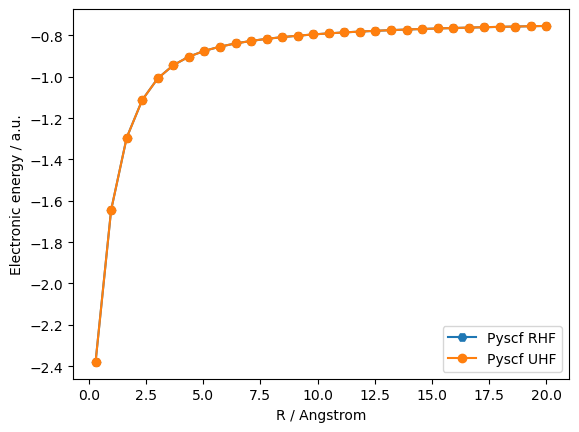

In [9]:
plt.plot(distances, RHF_eners, label="Pyscf RHF", marker="H")
plt.plot(distances, UHF_eners, label="Pyscf UHF", marker="o")
plt.xlabel("R / Angstrom")
plt.ylabel("Electronic energy / a.u.")
plt.legend()
plt.show()

And we can see that there is no notable difference. This is because it is necessary to break the symmetry of the alpha and beta density matrices. This is done by setting to zero the beta density of the 1s and 2s orbitals in the H case. 

In [10]:
UHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    kin = mol_He.intor("int1e_kin")
    vnuc = mol_He.intor("int1e_nuc")
    overlap = mol_He.intor("int1e_ovlp")
    eri = mol_He.intor("int2e")

    mf = scf.UHF(
        mol,

        
    )

    dm_alpha, dm_beta = mf.get_init_guess()
    dm_beta[:n_elec, :n_elec] = 0
    dm = (dm_alpha, dm_beta)

    e_He = mf.kernel(
        dm,
    )
    e_elec = mf.energy_elec()

    UHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850088436  <S^2> = 1.5822899e-12  2S+1 = 1
converged SCF energy = -1.10418469232614  <S^2> = 2.6441516e-11  2S+1 = 1
converged SCF energy = -1.01216162257868  <S^2> = 0.73471973  2S+1 = 1.9846609
converged SCF energy = -1.00004153616105  <S^2> = 0.96352906  2S+1 = 2.2032059
converged SCF energy = -0.998815630318712  <S^2> = 0.99498293  2S+1 = 2.2315761
converged SCF energy = -0.998684448522351  <S^2> = 0.99933487  2S+1 = 2.235473
converged SCF energy = -0.998671886883543  <S^2> = 0.99991657  2S+1 = 2.2359934
converged SCF energy = -0.998669318874865  <S^2> = 0.99999022  2S+1 = 2.2360592
converged SCF energy = -0.9986687870898  <S^2> = 0.9999989  2S+1 = 2.236067
converged SCF energy = -0.998668696024622  <S^2> = 0.99999987  2S+1 = 2.2360679
converged SCF energy = -0.99866864637642  <S^2> = 0.99999998  2S+1 = 2.236068
converged SCF energy = -0.998668636878133  <S^2> = 1  2S+1 = 2.236068
converged SCF energy = -0.998668635918826  <S^2> = 1  2S+1 = 2.236068


And we can see that there is a difference in the dissociation curve, as one would expect in the unrestricted case. 

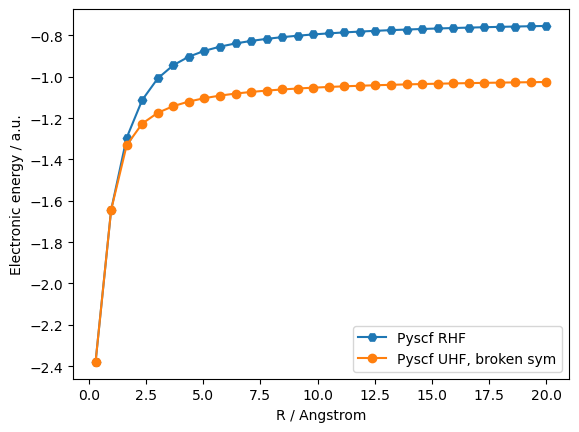

In [11]:
plt.plot(distances, RHF_eners, label="Pyscf RHF", marker="H")
plt.plot(distances, UHF_eners, label="Pyscf UHF, broken sym", marker="o")
plt.xlabel("R / Angstrom")
plt.ylabel("Electronic energy / a.u.")
plt.legend()
plt.show()

However, up to now, the guess for the SCF has been to use the core Hamiltonian. Using this approach directly results in no symmetry breaking, as the density matrix is composed of zeros in the guess. 

Therefore, in order to be able to break the symmetry, it is necessary a non-zero guess. In the current implementation here, we combine the RHF and UHF to start with a few iterations of the RHF in order to get a better guess of the density and then start the UHF loop from this density. 

We will compare now the densities between the pyscf formulation and this approach. 

converged SCF energy = -0.998668631839392  <S^2> = 1  2S+1 = 2.236068


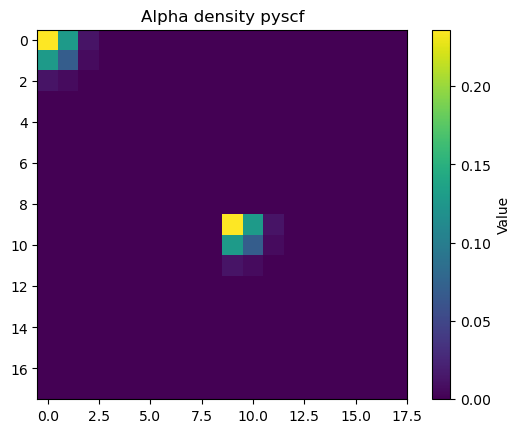

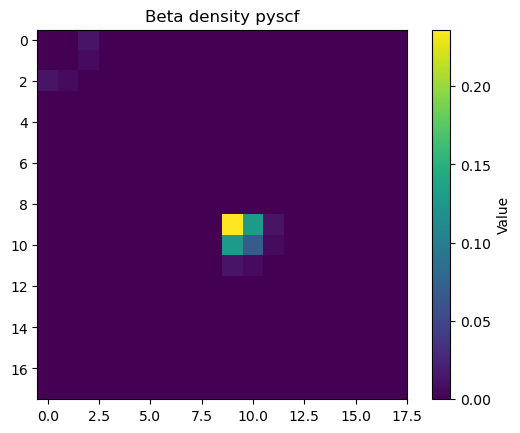

In [12]:
mol = gto.M(
    atom=f"  {element_1} 0 0 0; {element_2} 10 0 0;",
    spin=0,
    charge=0,
    basis=basis,
)

kin = mol.intor("int1e_kin")
vnuc = mol.intor("int1e_nuc")
overlap = mol.intor("int1e_ovlp")
eri = mol.intor("int2e")


mf = scf.UHF(
    mol,
)

dm_alpha, dm_beta = mf.get_init_guess()
dm_beta[:n_elec, :n_elec] = 0

dm = (dm_alpha, dm_beta)
mf.kernel(dm)

plot_map(dm_alpha, title="Alpha density pyscf")
plot_map(dm_beta, title="Beta density pyscf")

With the regular core guess

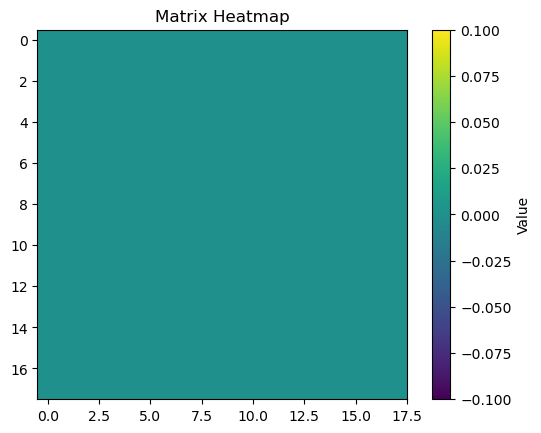

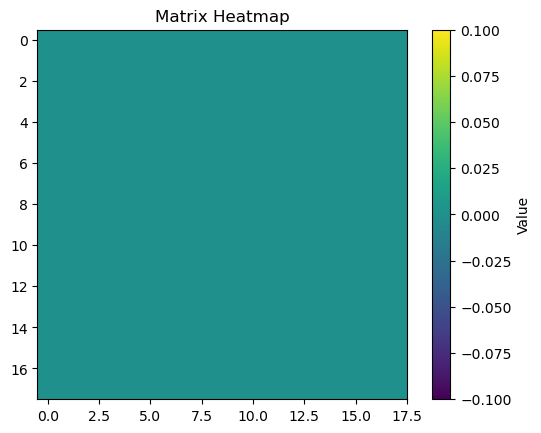

In [13]:
context = CSUHFContext(overlap, kin, vnuc, eri, n_electrons=n_elec, max_iter=1)

CS_UHF_results = CS_UHF(context)

plot_map(CS_UHF_results.P_guess_alpha.real)
plot_map(CS_UHF_results.P_guess_beta.real)

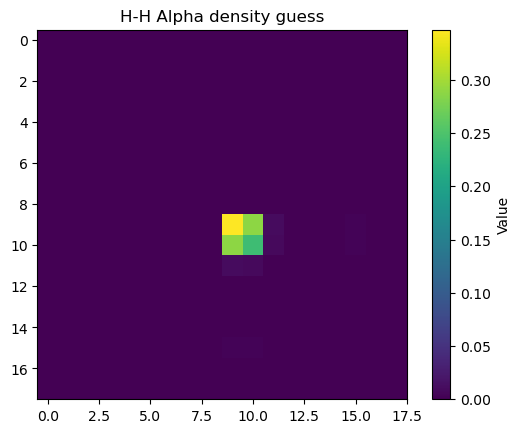

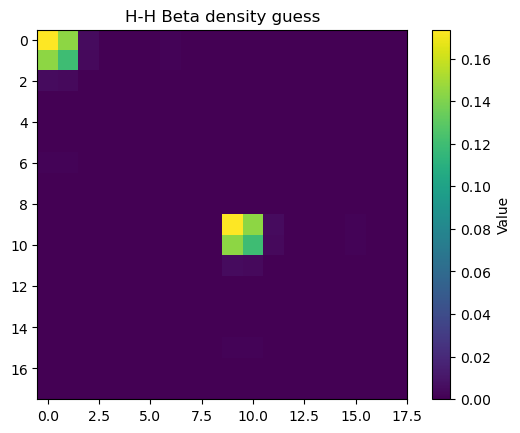

In [14]:
context = CSUHFContext(
    overlap,
    kin,
    vnuc,
    eri,
    n_electrons=n_elec,
    break_symm=True,
    max_iter=50,
    p_guess="RHF",
    
)

CS_UHF_results = CS_UHF(context)

plot_map(
    CS_UHF_results.P_guess_alpha.real,
    title=f"{element_1}-{element_2} Alpha density guess",
)
plot_map(
    CS_UHF_results.P_guess_beta.real,
    title=f"{element_1}-{element_2} Beta density guess",
)

In [15]:
print(CS_UHF_results.n_alpha)

1.0000000000000024


And the final densities:

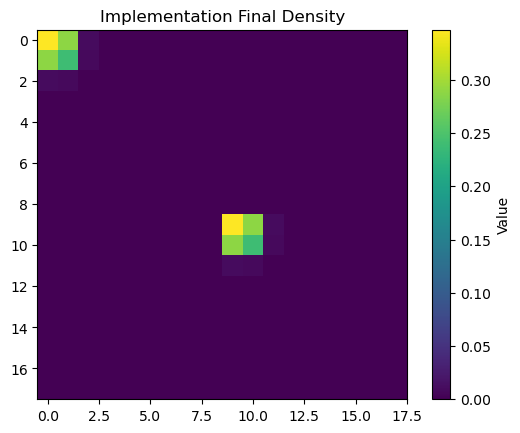

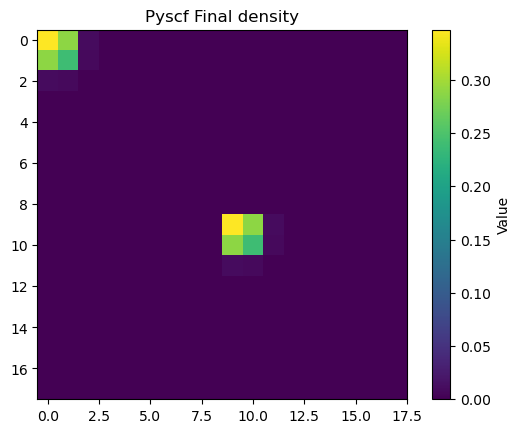

2.0000000000000027
2.0000000000000004


In [16]:
plot_map(CS_UHF_results.P_total.real, title="Implementation Final Density")
plot_map(mf.make_rdm1()[0] + mf.make_rdm1()[1], title="Pyscf Final density")
print(np.trace(CS_UHF_results.P_total.real @ CS_UHF_results.context.S))
print(np.trace((mf.make_rdm1()[0] + mf.make_rdm1()[1]) @ CS_UHF_results.context.S))

## Final dissociation curves
Here we can see the final dissociation curves using this `guess+bsymm` approach. It can be seen that even though in cases such as $HF$ the results are different to the pyscf ones, in both cases convergence is not achieved at longer distances. However, while pyscf seems to oscillate between the RHF and UHF, the implemented UHF presents the expected UHF tendency (even though it is not converged at these points).

In [17]:
Imp_RHF_eners = np.zeros_like(distances)
Imp_RHF_eners_core_guess = np.zeros_like(distances)

for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    kin = mol.intor("int1e_kin")
    vnuc = mol.intor("int1e_nuc")
    overlap = mol.intor("int1e_ovlp")
    eri = mol.intor("int2e")

    context = CSUHFContext(
        overlap,
        kin,
        vnuc,
        eri,
        n_electrons=n_elec,
        p_guess="RHF",
        break_symm=True,
        max_iter=200,
        _eigensolver = 'eigh'
    )

    CS_UHF_results = CS_UHF(context)
    print({dist}, CS_UHF_results.converged)
    Imp_RHF_eners[i] = CS_UHF_results.E_UHF.real


{np.float64(0.3)} True
{np.float64(0.9793103448275862)} True
{np.float64(1.6586206896551725)} True
{np.float64(2.3379310344827586)} True
{np.float64(3.0172413793103448)} True
{np.float64(3.696551724137931)} True
{np.float64(4.375862068965517)} True
{np.float64(5.055172413793104)} True
{np.float64(5.73448275862069)} True
{np.float64(6.413793103448276)} True
{np.float64(7.093103448275862)} True
{np.float64(7.772413793103448)} True
{np.float64(8.451724137931036)} True
{np.float64(9.131034482758622)} True
{np.float64(9.810344827586208)} True
{np.float64(10.489655172413794)} True
{np.float64(11.16896551724138)} True
{np.float64(11.848275862068967)} True
{np.float64(12.527586206896553)} True
{np.float64(13.206896551724139)} True
{np.float64(13.886206896551725)} True
{np.float64(14.565517241379311)} True
{np.float64(15.244827586206897)} True
{np.float64(15.924137931034483)} True
{np.float64(16.60344827586207)} True
{np.float64(17.282758620689656)} True
{np.float64(17.962068965517243)} True
{n

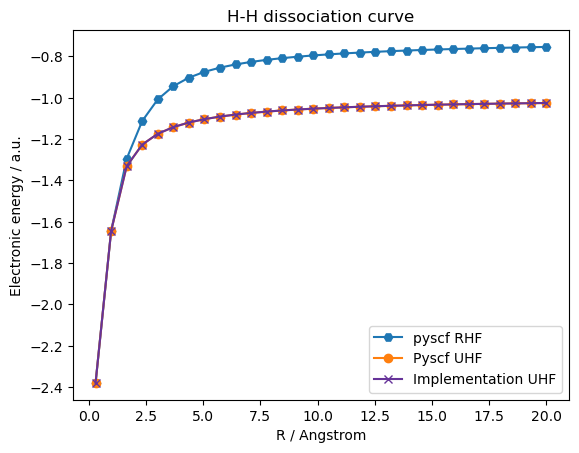

In [18]:
plt.plot(distances, RHF_eners, label="pyscf RHF", marker="H")
plt.plot(distances, UHF_eners, label="Pyscf UHF", marker="o")
plt.plot(
    distances, Imp_RHF_eners, label="Implementation UHF", marker="x", c="rebeccapurple"
)
plt.title(f"{element_1}-{element_2} dissociation curve")
plt.xlabel("R / Angstrom")
plt.ylabel("Electronic energy / a.u.")
plt.legend()
plt.show()

In [19]:
print(repr(UHF_eners))

array([-2.37960889, -1.6445417 , -1.33120817, -1.22638577, -1.17420008,
       -1.14183873, -1.11960285, -1.10334967, -1.09094864, -1.08117482,
       -1.07327311, -1.06675266, -1.06128038, -1.05662233, -1.05260937,
       -1.04911616, -1.04604788, -1.04333143, -1.04090959, -1.03873688,
       -1.03677675, -1.03499945, -1.03338055, -1.03189977, -1.03054016,
       -1.02928742, -1.02812945, -1.02705587, -1.02605778, -1.02512749])
